In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

daily = pd.read_csv('daily_aggregates.csv', parse_dates=['date'])
revenue = daily['revenue'].dropna()


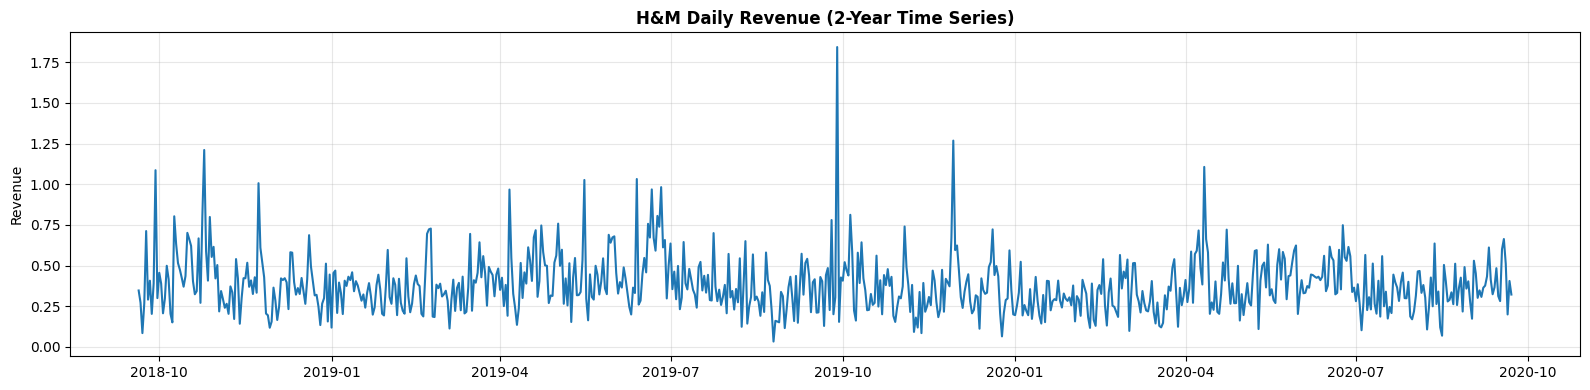

In [2]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily['date'], daily['revenue'], linewidth=1.5)
ax.set_title('H&M Daily Revenue (2-Year Time Series)', fontweight='bold')
ax.set_ylabel('Revenue')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('timeseries_raw.png', dpi=150)
plt.show()

In [3]:
result = adfuller(revenue)
print("=== AUGMENTED DICKEY-FULLER TEST ===")
print(f"ADF Statistic: {result[0]:.6f}")
print(f"P-value: {result[1]:.6f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.3f}")

if result[1] < 0.05:
    print("\n✓ STATIONARY (p < 0.05) → Use d=0 in SARIMA")
else:
    print("\n✗ NON-STATIONARY (p >= 0.05) → Use d=1 in SARIMA")


=== AUGMENTED DICKEY-FULLER TEST ===
ADF Statistic: -6.963943
P-value: 0.000000
Critical Values:
  1%: -3.439
  5%: -2.866
  10%: -2.569

✓ STATIONARY (p < 0.05) → Use d=0 in SARIMA


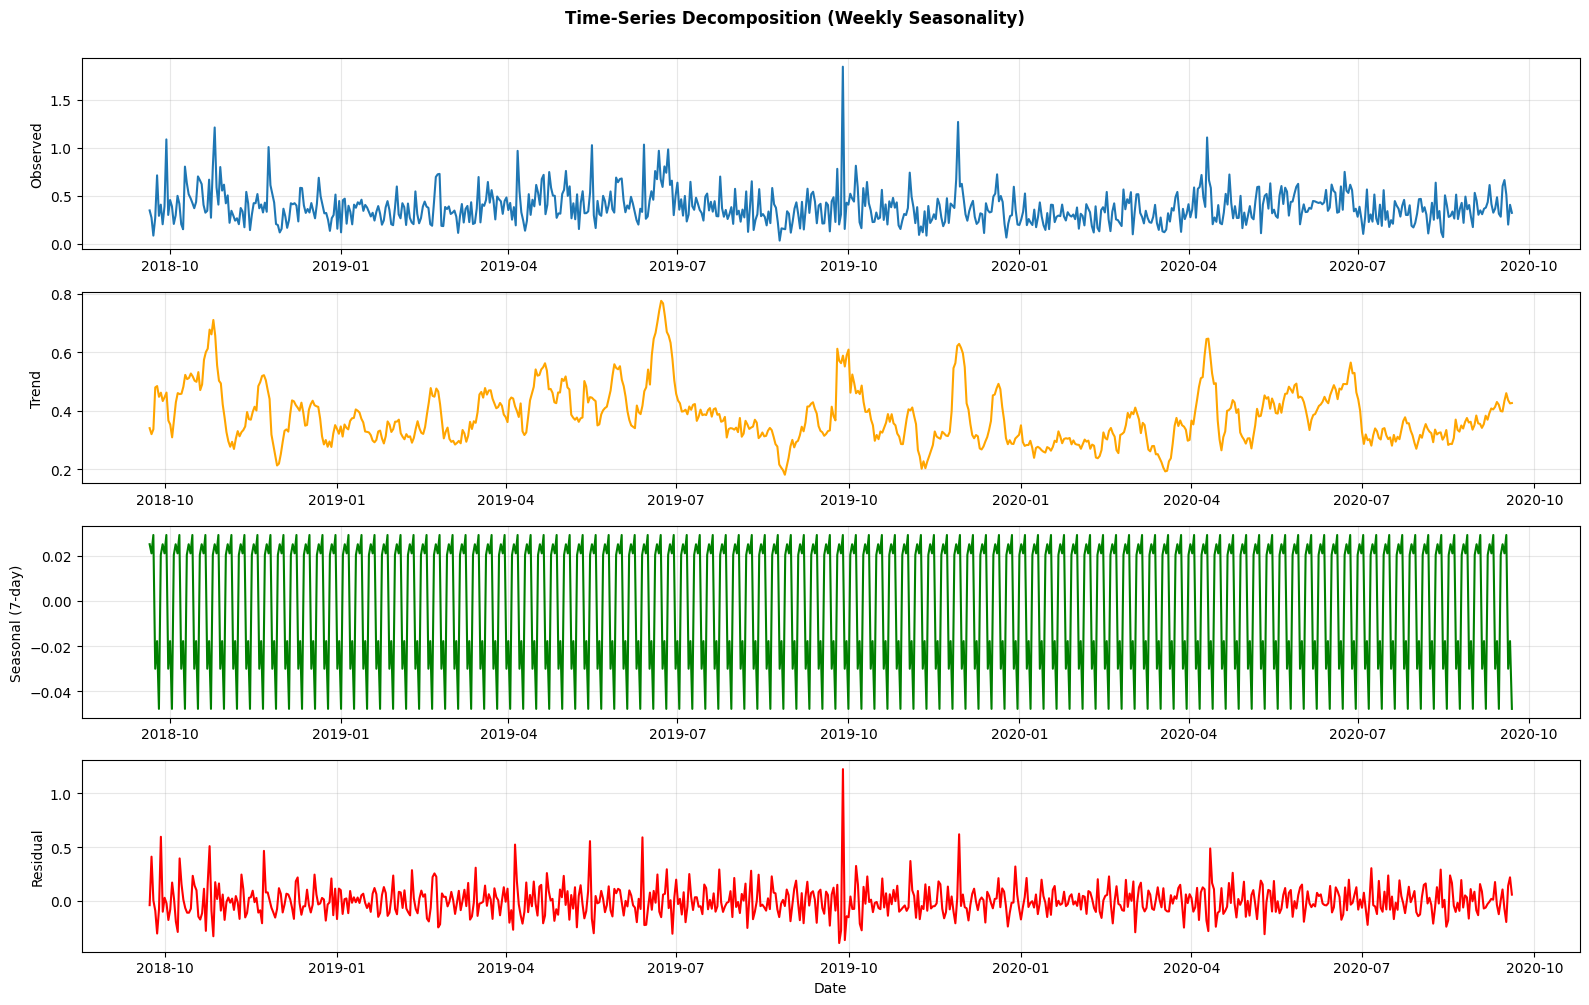

In [4]:
decomposition = seasonal_decompose(revenue, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
axes[0].plot(daily['date'], decomposition.observed, linewidth=1.5)
axes[0].set_ylabel('Observed')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily['date'], decomposition.trend, linewidth=1.5, color='orange')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily['date'], decomposition.seasonal, linewidth=1.5, color='green')
axes[2].set_ylabel('Seasonal (7-day)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(daily['date'], decomposition.resid, linewidth=1.5, color='red')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Time-Series Decomposition (Weekly Seasonality)', fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('timeseries_decomposition.png', dpi=150)
plt.show()


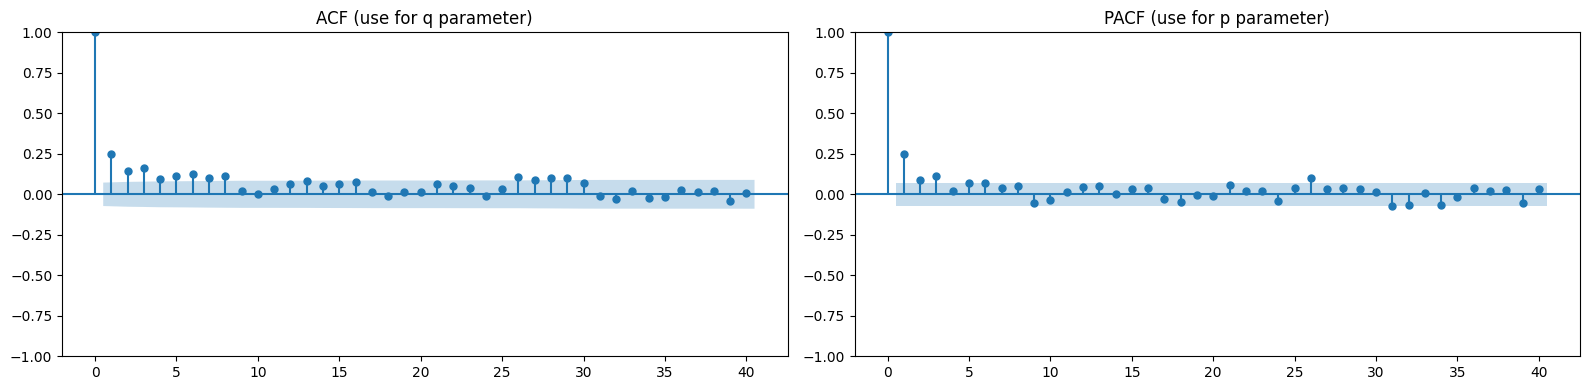


✅ Stationarity analysis complete. Plots saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(revenue, lags=40, ax=axes[0])
axes[0].set_title('ACF (use for q parameter)')
plot_pacf(revenue, lags=40, ax=axes[1])
axes[1].set_title('PACF (use for p parameter)')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

print("\n✅ Stationarity analysis complete. Plots saved.")
